# Comparación de Métodos Numéricos para Modelado de Angiogénesis

Rodrigo Martínez Escalante | A00838495

Luis Roberto Campos Solís | A00838686

Mariana Villarreal R. Vela | A01722821

Santiago Rodriguez | A01198752

Karla Sofía Cantú Zendejas | A01285550

Diego Armando Mijares | A01722421

## Introducción

En este notebook se presentan tres métodos numéricos diferentes para resolver la ecuación diferencial de angiogénesis:
- Runge-Kutta de 4to orden (RK4)
- Método de Euler
- Red Neuronal Informada por Física (PINN)

## Importaciones Necesarias


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import sys

2024-12-01 21:20:18.720370: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Definición de Parámetros Comunes

In [2]:
# Parámetros del sistema
k_g = 0.015  # Tasa de crecimiento de tumores
k_1 = 0.15   # Tasa de proliferación de células endoteliales

# Condiciones iniciales
T_0 = 20     # Tumor inicial
E_0 = 60     # Células endoteliales iniciales

# Configuraciones de simulación
t0 = 0       # Tiempo inicial
t_f = 1000    # Tiempo final
h = 0.1      # Paso temporal

## Método 1: Runge-Kutta de 4to Orden (RK4)

In [3]:
def dxdt(x, y):
    return k_g * x * (1 - x / y)

def dydt(x, y):
    return k_1 * np.sqrt(x)

def runge_kutta_system(dxdt, dydt, x0, y0, t0, t_f, h):
    t = np.arange(t0, t_f + h, h)
    x = np.zeros_like(t)
    y = np.zeros_like(t)
    x[0] = x0
    y[0] = y0
    
    for i in range(1, len(t)):
        k1x = h * dxdt(x[i - 1], y[i - 1])
        k1y = h * dydt(x[i - 1], y[i - 1])
        
        k2x = h * dxdt(x[i - 1] + k1x / 2, y[i - 1] + k1y / 2)
        k2y = h * dydt(x[i - 1] + k1x / 2, y[i - 1] + k1y / 2)
        
        k3x = h * dxdt(x[i - 1] + k2x / 2, y[i - 1] + k2y / 2)
        k3y = h * dydt(x[i - 1] + k2x / 2, y[i - 1] + k2y / 2)
        
        k4x = h * dxdt(x[i - 1] + k3x, y[i - 1] + k3y)
        k4y = h * dydt(x[i - 1] + k3x, y[i - 1] + k3y)
        
        x[i] = x[i - 1] + (k1x + 2 * k2x + 2 * k3x + k4x) / 6
        y[i] = y[i - 1] + (k1y + 2 * k2y + 2 * k3y + k4y) / 6
    
    return t, x, y

# Simulación RK4
t_rk4, x_rk4, y_rk4 = runge_kutta_system(dxdt, dydt, T_0, E_0, t0, t_f, h)

### Visualización de Resultados RK4

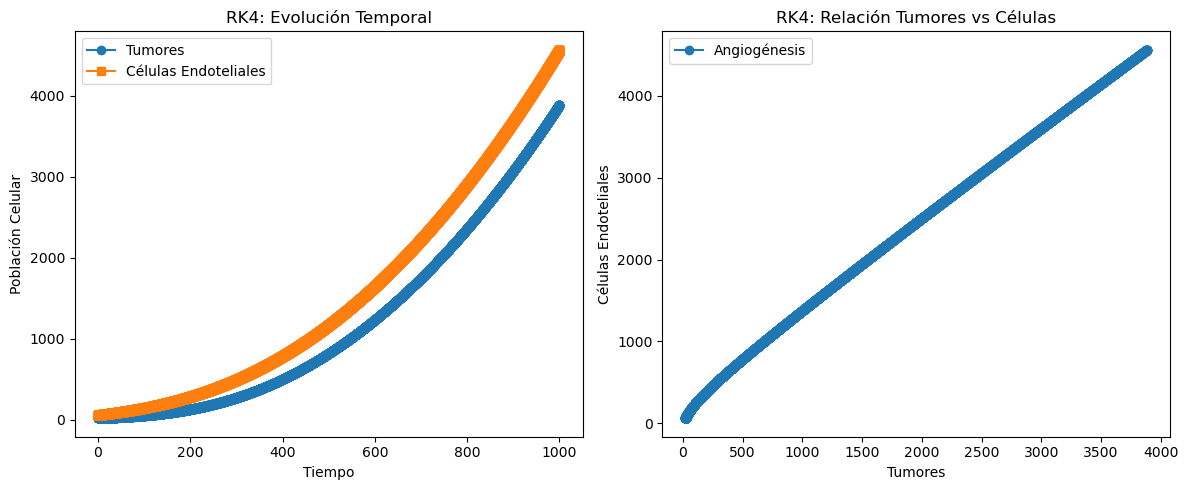

In [4]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(t_rk4, x_rk4, label='Tumores', marker='o')
plt.plot(t_rk4, y_rk4, label='Células Endoteliales', marker='s')
plt.title('RK4: Evolución Temporal', fontsize=12)
plt.xlabel('Tiempo', fontsize=10)
plt.ylabel('Población Celular', fontsize=10)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x_rk4, y_rk4, label='Angiogénesis', marker='o')
plt.title('RK4: Relación Tumores vs Células', fontsize=12)
plt.xlabel('Tumores', fontsize=10)
plt.ylabel('Células Endoteliales', fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

Se observa el crecimiento exponencial para la primera gráfica, y un crecimiento lineal (después de un comportamiento levemente inverso exponencial) en la segunda gráfica.

Para visualizar de distintas formas, haremos el mismo método, ahora con un tiempo de 10.

## Método 1: Runge-Kutta de 4to Orden (RK4) T = 10



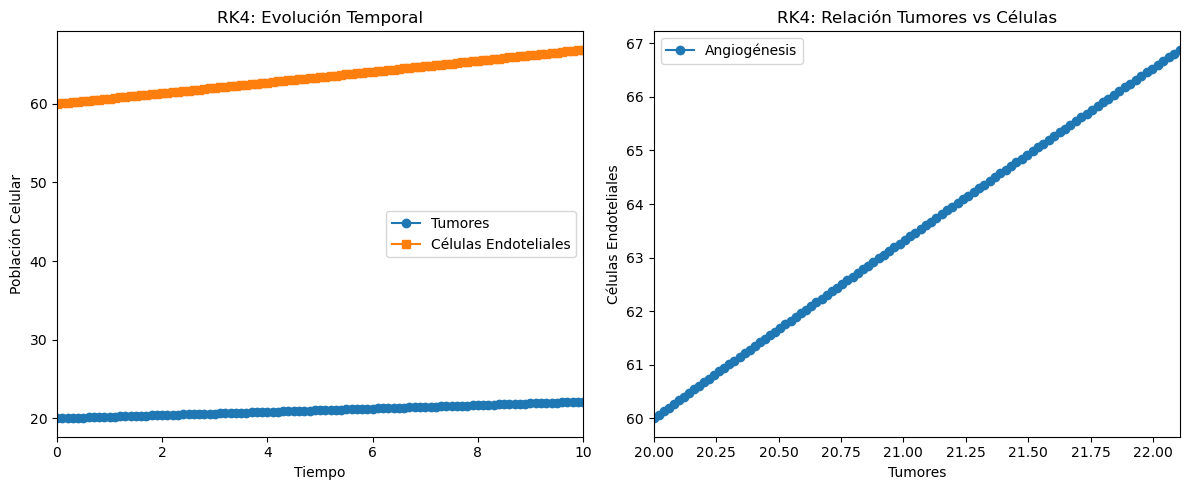

In [21]:
t_f = 10

def dxdt(x, y):
    return k_g * x * (1 - x / y)

def dydt(x, y):
    return k_1 * np.sqrt(x)

def runge_kutta_system(dxdt, dydt, x0, y0, t0, t_f, h):
    t = np.arange(t0, t_f + h, h)
    x = np.zeros_like(t)
    y = np.zeros_like(t)
    x[0] = x0
    y[0] = y0
    
    for i in range(1, len(t)):
        k1x = h * dxdt(x[i - 1], y[i - 1])
        k1y = h * dydt(x[i - 1], y[i - 1])
        
        k2x = h * dxdt(x[i - 1] + k1x / 2, y[i - 1] + k1y / 2)
        k2y = h * dydt(x[i - 1] + k1x / 2, y[i - 1] + k1y / 2)
        
        k3x = h * dxdt(x[i - 1] + k2x / 2, y[i - 1] + k2y / 2)
        k3y = h * dydt(x[i - 1] + k2x / 2, y[i - 1] + k2y / 2)
        
        k4x = h * dxdt(x[i - 1] + k3x, y[i - 1] + k3y)
        k4y = h * dydt(x[i - 1] + k3x, y[i - 1] + k3y)
        
        x[i] = x[i - 1] + (k1x + 2 * k2x + 2 * k3x + k4x) / 6
        y[i] = y[i - 1] + (k1y + 2 * k2y + 2 * k3y + k4y) / 6
    
    return t, x, y

# Simulación RK4
t_rk4, x_rk4, y_rk4 = runge_kutta_system(dxdt, dydt, T_0, E_0, t0, t_f, h)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(t_rk4, x_rk4, label='Tumores', marker='o')
plt.plot(t_rk4, y_rk4, label='Células Endoteliales', marker='s')
plt.title('RK4: Evolución Temporal', fontsize=12)
plt.xlabel('Tiempo', fontsize=10)
plt.ylabel('Población Celular', fontsize=10)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x_rk4, y_rk4, label='Angiogénesis', marker='o')
plt.title('RK4: Relación Tumores vs Células', fontsize=12)
plt.xlabel('Tumores', fontsize=10)
plt.ylabel('Células Endoteliales', fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

## Método 2: Método de Euler

In [5]:
def euler_method(T_0, E_0, dt, t_max):
    n_steps = int(t_max / dt)
    T = np.zeros(n_steps)
    E = np.zeros(n_steps)
    t = np.linspace(0, t_max, n_steps)
    
    T[0] = T_0
    E[0] = E_0
    
    for i in range(n_steps - 1):
        dT_dt = k_g * T[i] * (1 - T[i] / E[i])
        dE_dt = k_1 * T[i] ** 0.5
        
        T[i + 1] = T[i] + dT_dt * dt
        E[i + 1] = E[i] + dE_dt * dt
    
    return t, T, E

# Simulación Euler
t_euler, T_euler, E_euler = euler_method(T_0, E_0, h, t_f)

### Visualización de Resultados Euler


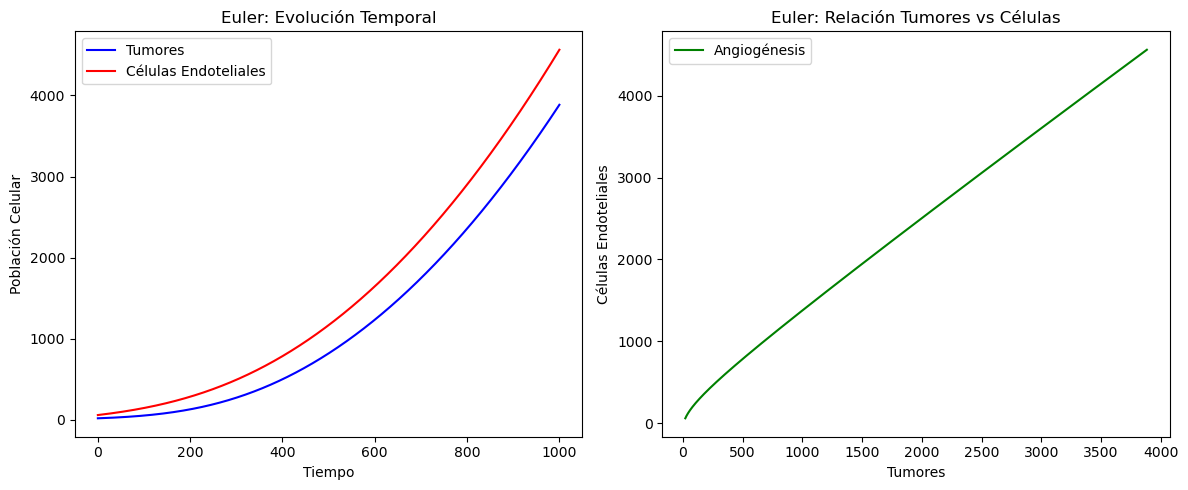

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(t_euler, T_euler, label='Tumores', color='blue')
plt.plot(t_euler, E_euler, label='Células Endoteliales', color='red')
plt.title('Euler: Evolución Temporal', fontsize=12)
plt.xlabel('Tiempo', fontsize=10)
plt.ylabel('Población Celular', fontsize=10)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(T_euler, E_euler, label='Angiogénesis', color='green')
plt.title('Euler: Relación Tumores vs Células', fontsize=12)
plt.xlabel('Tumores', fontsize=10)
plt.ylabel('Células Endoteliales', fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

Se observa el crecimiento exponencial para la primera gráfica, y un crecimiento lineal (después de un comportamiento levemente inverso exponencial) en la segunda gráfica.

Para visualizar de distintas formas, haremos el mismo método, ahora con un tiempo de 10.

## Método 2: Método de Euler T=10

In [7]:
t_f = 10

def euler_method(T_0, E_0, dt, t_max):
    n_steps = int(t_max / dt)
    T = np.zeros(n_steps)
    E = np.zeros(n_steps)
    t = np.linspace(0, t_max, n_steps)
    
    T[0] = T_0
    E[0] = E_0
    
    for i in range(n_steps - 1):
        dT_dt = k_g * T[i] * (1 - T[i] / E[i])
        dE_dt = k_1 * T[i] ** 0.5
        
        T[i + 1] = T[i] + dT_dt * dt
        E[i + 1] = E[i] + dE_dt * dt
    
    return t, T, E

# Simulación Euler
t_euler, T_euler, E_euler = euler_method(T_0, E_0, h, t_f)

### Visualización de nuevos resultados

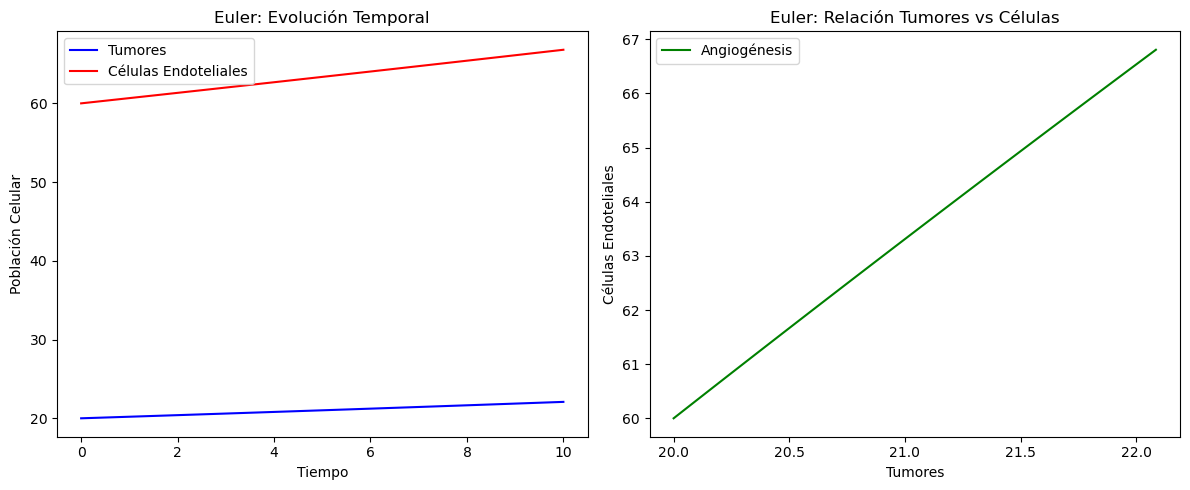

In [8]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(t_euler, T_euler, label='Tumores', color='blue')
plt.plot(t_euler, E_euler, label='Células Endoteliales', color='red')
plt.title('Euler: Evolución Temporal', fontsize=12)
plt.xlabel('Tiempo', fontsize=10)
plt.ylabel('Población Celular', fontsize=10)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(T_euler, E_euler, label='Angiogénesis', color='green')
plt.title('Euler: Relación Tumores vs Células', fontsize=12)
plt.xlabel('Tumores', fontsize=10)
plt.ylabel('Células Endoteliales', fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

## Método 3: Red Neuronal Informada por Física (PINN)

In [13]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


# Crear el modelo con dos salidas (para T y E)
u_hat = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=(1,)),  # Entradas de t
    tf.keras.layers.Dense(32, activation='sigmoid'),
    tf.keras.layers.Dense(2, activation='relu')  # Salidas no negativas
])

u_hat.summary()


# Parámetros
K_g = 0.015  
K_1 = 0.15  

# Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)


# Condiciones iniciales
T_0 = 20
E_0 = 60

def loss_function(t, model):
    t = tf.convert_to_tensor(t, dtype=tf.float32)
    
    with tf.GradientTape() as tape1, tf.GradientTape() as tape2:
        tape1.watch(t)
        tape2.watch(t)
        u = model(t)  # Salidas: [T(t), E(t)]
        dT_dt = tape1.gradient(u[:, 0], t)
        dE_dt = tape2.gradient(u[:, 1], t)
    
    # Evitar valores cercanos a cero
    T = tf.maximum(u[:, 0], 1e-6)
    E = tf.maximum(u[:, 1], 1e-6)

    # Ecuaciones diferenciales
    physics_loss_T = dT_dt - K_g * T * (1 - T / E)
    physics_loss_E = dE_dt - K_1 * tf.sqrt(T)

    # Pérdida de datos: condición inicial en t=0
    data_loss = tf.reduce_mean(tf.square(u[0, 0] - T_0)) + tf.reduce_mean(tf.square(u[0, 1] - E_0))

    # Pérdidas cuadráticas
    total_loss = (
        tf.reduce_mean(tf.square(physics_loss_T)) +
        tf.reduce_mean(tf.square(physics_loss_E)) +
        data_loss
    )

    return total_loss


# Generar los datos de entrenamiento para t
t_train = np.linspace(0, 2, 21).reshape(-1, 1)  # 21 puntos de entrenamiento

# Número de iteraciones para el entrenamiento
iterations = 10000
function_loss = []

# Bucle de entrenamiento
for i in range(iterations):
    with tf.GradientTape() as tape:
        train_loss = loss_function(t_train, u_hat)
        function_loss.append(train_loss)
        grad_w = tape.gradient(train_loss, u_hat.trainable_variables)
        optimizer.apply_gradients(zip(grad_w, u_hat.trainable_variables))

    if i % 1000 == 0:
        print(f"Iteración {i} - Pérdida: {train_loss.numpy()}.")





Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130 (520.00 B)

 Trainable params: 130 (520.00 B)

 Non-trainable params: 0 (0.00 B)

Iteración 0 - Pérdida: 3866.691162109375.
Iteración 1000 - Pérdida: 1177.7606201171875.
Iteración 2000 - Pérdida: 123.95620727539062.
Iteración 3000 - Pérdida: 2.488947629928589.
Iteración 4000 - Pérdida: 0.0577346533536911.
Iteración 5000 - Pérdida: 0.051458340138196945.
Iteración 6000 - Pérdida: 0.0463506355881691.
Iteración 7000 - Pérdida: 0.039406873285770416.
Iteración 8000 - Pérdida: 0.03085654228925705.
Iteración 9000 - Pérdida: 0.021710794419050217.


### Visualización de la Pérdida PINN

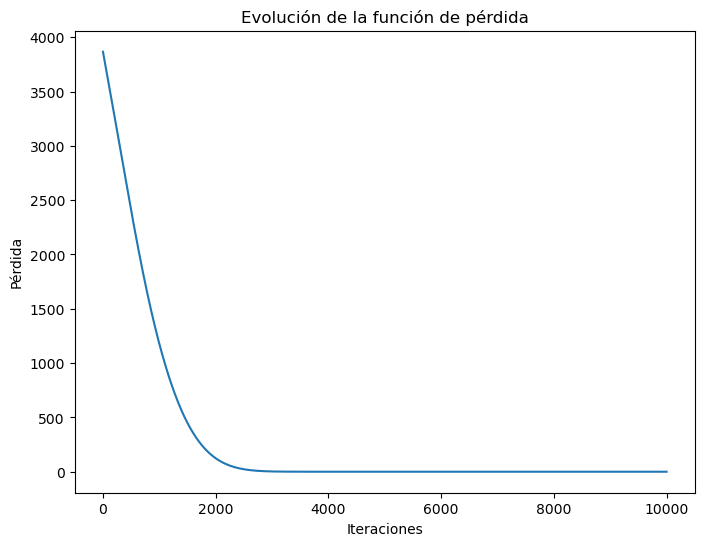

In [14]:
# Graficar la pérdida a lo largo de las iteraciones
plt.figure(figsize=(8, 6))
plt.plot(function_loss)
plt.xlabel("Iteraciones")
plt.ylabel("Pérdida")
plt.title("Evolución de la función de pérdida")
plt.show()

### Gráficas de PINN adicionales

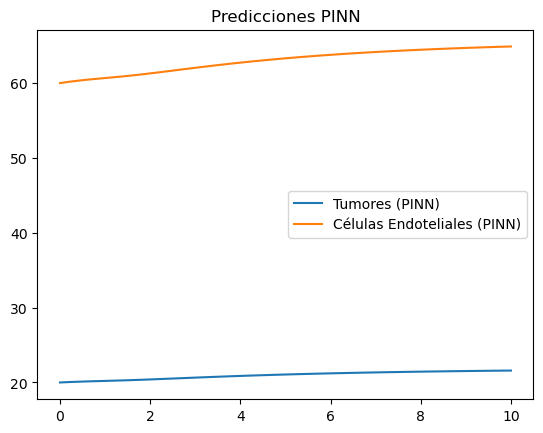

In [15]:
def predict_pinn(model, t_range):
    t_pred = tf.convert_to_tensor(t_range.reshape(-1, 1), dtype=tf.float32)
    predictions = model(t_pred).numpy()
    return t_range, predictions[:, 0], predictions[:, 1]

# Rango de tiempo para predicción
t_pinn_range = np.linspace(0, t_f, int(t_f/h))
t_pinn, T_pinn, E_pinn = predict_pinn(u_hat, t_pinn_range)

plt.plot(t_pinn, T_pinn, label='Tumores (PINN)')
plt.plot(t_pinn, E_pinn, label='Células Endoteliales (PINN)')
plt.legend()
plt.title("Predicciones PINN")
plt.show()

## Comparación de Métricas

Para comparar los métodos, calcularemos algunas métricas relevantes:

Métricas RK4:
max_growth_rate: 0.22188630182011415
inflection_point: 98
stability: 4.0326070369467854e-07

Métricas Euler:
max_growth_rate: 0.2193200039654866
inflection_point: 97
stability: 3.9431924211838223e-07

Métricas PINN:
max_growth_rate: 0.28643245697021485
inflection_point: 14
stability: 3.908666258212179e-05


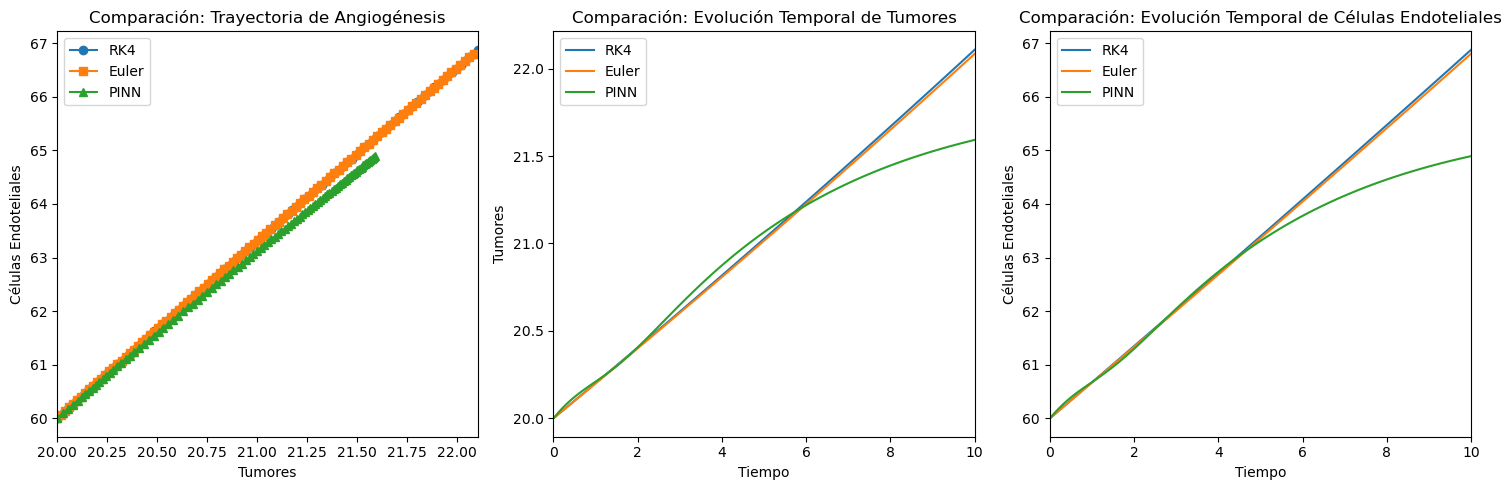

In [22]:
def compute_metrics(t, x, y):
    # Tasa de crecimiento máxima
    max_growth_rate = np.max(np.diff(x) / np.diff(t))
    
    # Punto de inflexión
    inflection_point = np.argmax(np.diff(np.diff(x)))
    
    # Estabilidad (varianza de los incrementos)
    stability = np.var(np.diff(x))
    
    return {
        'max_growth_rate': max_growth_rate,
        'inflection_point': inflection_point,
        'stability': stability
    }

# Métricas para cada método
metrics_rk4 = compute_metrics(t_rk4, x_rk4, y_rk4)
metrics_euler = compute_metrics(t_euler, T_euler, E_euler)
metrics_pinn = compute_metrics(t_pinn, T_pinn, E_pinn)

print("Métricas RK4:")
for k, v in metrics_rk4.items():
    print(f"{k}: {v}")

print("\nMétricas Euler:")
for k, v in metrics_euler.items():
    print(f"{k}: {v}")

print("\nMétricas PINN:")
for k, v in metrics_pinn.items():
    print(f"{k}: {v}")

# Comparación visual de la trayectoria
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(x_rk4, y_rk4, label='RK4', marker='o')
plt.plot(T_euler, E_euler, label='Euler', marker='s')
plt.plot(T_pinn, E_pinn, label='PINN', marker='^')
plt.title('Comparación: Trayectoria de Angiogénesis', fontsize=12)
plt.xlabel('Tumores', fontsize=10)
plt.ylabel('Células Endoteliales', fontsize=10)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(t_rk4, x_rk4, label='RK4')
plt.plot(t_euler, T_euler, label='Euler')
plt.plot(t_pinn, T_pinn, label='PINN')
plt.title('Comparación: Evolución Temporal de Tumores', fontsize=12)
plt.xlabel('Tiempo', fontsize=10)
plt.ylabel('Tumores', fontsize=10)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(t_rk4, y_rk4, label='RK4')
plt.plot(t_euler, E_euler, label='Euler')
plt.plot(t_pinn, E_pinn, label='PINN')
plt.title('Comparación: Evolución Temporal de Células Endoteliales', fontsize=12)
plt.xlabel('Tiempo', fontsize=10)
plt.ylabel('Células Endoteliales', fontsize=10)
plt.legend()

plt.tight_layout()
plt.show()


Cabe resaltar que en la primer gráfica no se observa la línea azul porque cae directamente abajo de la naranja.

## Conclusiones

Este notebook compara tres métodos numéricos para modelar la evolución de un sistema de angiogénesis:

1. **Runge-Kutta de 4to Orden (RK4)**: 
   - Método de alta precisión
   - Captura dinámicas complejas
   - Computacionalmente más costoso

2. **Método de Euler**:
   - Método más simple
   - Menor precisión
   - Computacionalmente eficiente

3. **Red Neuronal Informada por Física (PINN)**:
   - Método moderno basado en aprendizaje
   - Integra conocimiento físico en la red neuronal
   - Potencial para adaptarse a sistemas no lineales

### Interpretación de las gráficas

1. **Primera gráfica (Trayectoria de Angiogénesis):**
   - **RK4 (azul)** y **Euler (naranja)** siguen exactamente la misma trayectoria lineal, lo que indica que estos métodos producen resultados equivalentes para este caso.
   - **PINN (verde)** también sigue una línea recta, pero está ligeramente por debajo de las otras dos, lo que sugiere que este método puede subestimar el crecimiento angiogénico.

2. **Segunda gráfica (Evolución Temporal de Tumores):**
   - **RK4 (azul)** y **Euler (naranja)** muestran un crecimiento casi idéntico, siendo RK4 marginalmente más alto.
   - **PINN (verde)** tiene un comportamiento diferente: presenta un crecimiento inicial ligeramente más fuerte, seguido de una estabilización alrededor de 21.5, lo que podría ser indicativo de que este método modela una dinámica biológica más realista (crecimiento y saturación).

3. **Tercera gráfica (Evolución Temporal de Células Endoteliales):**
   - Nuevamente, **RK4 (azul)** y **Euler (naranja)** tienen trayectorias casi idénticas.
   - **PINN (verde)** sigue un comportamiento similar al observado en la segunda gráfica: crecimiento más ligeramente más fuerte y eventual estabilización, esta vez alrededor de 64.5.


### Análisis de las métricas

1. **Tasa máxima de crecimiento (`max_growth_rate`):**
   - **RK4:** 0.2219
   - **Euler:** 0.2193
   - **PINN:** 0.2864 (la más alta)

   **Interpretación:** PINN presenta la tasa de crecimiento más alta, lo que indica que puede capturar un comportamiento más dinámico en la etapa inicial del crecimiento.

2. **Punto de inflexión (`inflection_point`):**
   - **RK4:** 98
   - **Euler:** 97
   - **PINN:** 14 (mucho más temprano)

   **Interpretación:** PINN detecta cambios en la dinámica del sistema mucho antes que RK4 y Euler, lo que podría ser una ventaja si se busca modelar comportamientos no lineales y saturaciones biológicas.

3. **Estabilidad (`stability`):**
   - **RK4:** 4.03e-07 (la más estable)
   - **Euler:** 3.94e-07
   - **PINN:** 3.91e-05 (la menos estable)

   **Interpretación:** RK4 y Euler son significativamente más estables que PINN, lo que es importante si se prioriza la consistencia numérica.


### ¿Cuál es el mejor método?

La elección del mejor método depende del contexto y objetivos del modelo:
- **Si buscas precisión numérica y estabilidad**, RK4 es la mejor opción, seguido de Euler.
- **Si prefieres un modelo que capture dinámicas no lineales y saturaciones biológicas más realistas**, entonces PINN es más adecuado, aunque con menor estabilidad.

En un contexto biológico donde la saturación o estabilización es crucial, **PINN sería la mejor opción**. Sin embargo, para cálculos puramente matemáticos o donde la estabilidad sea prioritaria, **RK4 es preferible**.